# Tridiagonal matrix solver

Here we'll solve the equation:

$$f^{\prime\prime} = g(x)$$

with $g(x) = sin(x)$, and the domain $x \in [0, 2\pi]$, with boundary conditions $f(0) = f(2\pi) = 0$.  The solution is simply $f(x) = -sin(x)$.

We'll use a grid of $N$ points with $x_0$ on the left boundary and $x_{N-1}$ on the right boundary.

We difference our equation according to the finite differences scheme, namely

$$\frac{f_{i+1} - 2 f_i + f_{i-1}}{\Delta x^2} = g_i$$

We keep the boundary points fixed, so we only need to solve for the $N-2$ interior points.  Near the boundaries, our difference is:
$$f_2 - 2 f_1 = \Delta x^2 g_1$$

and

$$-2f_{N-1} + f_{N-2} = \Delta x^2 g_{N-1}$$.

We can write the system of equations for solving for the $N-2$ interior points as:

\begin{equation}
A = \left (
\begin{array}{ccccccc}
-2 &  1 &    &        &         &           &          \newline
1  & -2 &  1 &        &         &           &          \newline
   &  1 & -2 & 1      &         &           &          \newline
   &         & \ddots & \ddots & \ddots  &           &          \newline
   &         &        & \ddots & \ddots  & \ddots  &          \newline
   &         &        &        & 1       & -2 & 1  \newline
   &         &        &        &         & 1  & -2 \newline
\end{array}
\right )
\end{equation}

\begin{equation}
x = \left (
\begin{array}{c}
f_\mathrm{1} \\\
f_\mathrm{2} \\\
f_\mathrm{3} \\\
\vdots \\\
\vdots \\\
f_\mathrm{N-2} \\\
f_\mathrm{N-1} \\\
\end{array}
\right )
\end{equation}

\begin{equation}
b = \Delta x^2 \left (
\begin{array}{c}
g_\mathrm{1} \\\
g_\mathrm{2} \\\
g_\mathrm{3} \\\
\vdots \\\
\vdots \\\
g_\mathrm{N-2} \\\
g_\mathrm{N-1}\\\
\end{array}
\right )
\end{equation}

Then we just solve $A x = b$

### Solution using numpy

In [0]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [0]:
# our grid -- including endpoints
N = 100
x = np.linspace(0.0, 2.0*np.pi, N, endpoint=True)
dx = x[1]-x[0]

# our source
g = np.sin(x)

In [13]:
# check defintion of our grid
x.shape, x[0], x[N-1]

((100,), 0.0, 6.283185307179586)

In [6]:
# alternative definition of the grid
dxx = 2.0*np.pi/(N-1)
#xx = np.arange(0.0, 2.0*np.pi, dxx)
xx = np.arange(0.0, 2.0*np.pi+dxx, dxx)

print(dx == dxx)
xx.shape
x == xx

True


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [14]:
# our matrix will be tridiagonal, with [1, -2, 1] on the diagonals
# we only solve for the N-2 interior points

# diagonal
e = np.ones(N-2)
d =-2*e
# upper and lower diagonal parts
e1 = np.ones(N-3)
u=e1
l=e1

#np.diag(u,1)
Af=np.diag(d)+np.diag(u,1)+np.diag(l,-1)
print(Af)

[[-2.  1.  0. ...  0.  0.  0.]
 [ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]
 [ 0.  0.  0. ...  0.  1. -2.]]


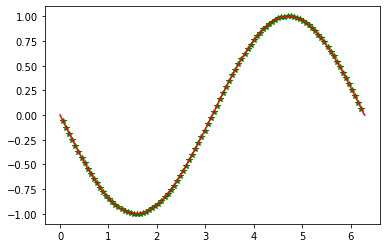

In [15]:
# solve the linear system using numpy
xf=np.linalg.solve(Af,dx**2*g[1:N-1])

# plot the approximating solution
plt.plot(x[1:N-1], xf, 'g*')

# compare with exact solution
y = np.linspace(0.0, 2.0*np.pi, 200)
f = -np.sin(y)
plt.plot(y, f,'r')
plt.show()

In [17]:
# compute errors
err = xf + np.sin(x[1:N-1])
err_inf = np.linalg.norm(err, np.inf)
err_2 = np.linalg.norm(err)

print(err_inf, err_2)

# help(np.linalg.norm)

0.0003356919326750196 0.002362099420095094


####Exercise

Assess the performance of the scheme by plotting the convergence behavior for $N = 10, 20, 40, 80, \ldots$

###Solution using scipy

  (0, 0)	-2.0
  (1, 0)	1.0
  (1, 1)	-2.0
  (2, 1)	1.0
  (0, 1)	1.0
  (2, 2)	-2.0
  (3, 2)	1.0
  (1, 2)	1.0
  (3, 3)	-2.0
  (4, 3)	1.0
  (2, 3)	1.0
  (4, 4)	-2.0
  (5, 4)	1.0
  (3, 4)	1.0
  (5, 5)	-2.0
  (6, 5)	1.0
  (4, 5)	1.0
  (6, 6)	-2.0
  (7, 6)	1.0
  (5, 6)	1.0
  (7, 7)	-2.0
  (8, 7)	1.0
  (6, 7)	1.0
  (8, 8)	-2.0
  (9, 8)	1.0
  :	:
  (90, 89)	1.0
  (88, 89)	1.0
  (90, 90)	-2.0
  (91, 90)	1.0
  (89, 90)	1.0
  (91, 91)	-2.0
  (92, 91)	1.0
  (90, 91)	1.0
  (92, 92)	-2.0
  (93, 92)	1.0
  (91, 92)	1.0
  (93, 93)	-2.0
  (94, 93)	1.0
  (92, 93)	1.0
  (94, 94)	-2.0
  (95, 94)	1.0
  (93, 94)	1.0
  (95, 95)	-2.0
  (96, 95)	1.0
  (94, 95)	1.0
  (96, 96)	-2.0
  (97, 96)	1.0
  (95, 96)	1.0
  (97, 97)	-2.0
  (96, 97)	1.0


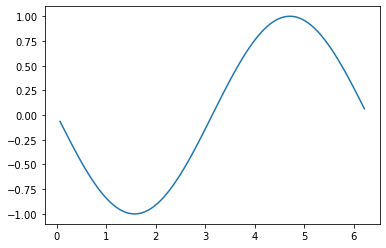

In [18]:
import scipy.linalg as linalg
from scipy.sparse import spdiags
from scipy.sparse.linalg import spsolve

data = np.array([d, e, e])
diags = np.array([0, -1, 1])

As = spdiags(data, diags, N-2, N-2).tocsc()
print(As)

xs = spsolve(As,dx**2*g[1:N-1])

plt.plot(x[1:N-1], xs)

# upper -- note that the upper diagonal has 1 less element than the
# main diagonal.  The SciPy banded solver wants the matrix in the 
# form:
#
# *    a01  a12  a23  a34  a45    <- upper diagonal
# a00  a11  a22  a33  a44  a55    <- diagonal
# a10  a21  a32  a43  a54   *     <- lower diagonal
#

u = np.ones(N-2)
u[0] = 0.0

# lower
l = np.ones(N-2)
l[N-3] = 0.0

# put the upper, diagonal, and lower parts together as a banded matrix
A = np.matrix([u,d,l])

# solve A sol = dx**2 g for the inner N-2 points
sol = linalg.solve_banded((1,1), A, dx**2*g[1:N-1])

#plt.plot(x[1:N-1], xs)